In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os


def create_and_save_heatmap(exp_name, data_path):
    # Read the JSONL file
    with open(data_path, 'r') as file:
        lines = file.readlines()

    # Determine the maximum attempt_id and the size of the number set
    max_attempt_id = 0
    number_set_size = 0

    for line in lines:
        data = json.loads(line)
        attempt_id = data.get("attempt_id", 0)
        number_set = data["extra_info"].get("number_set") or data["extra_info"].get("support")
        
        max_attempt_id = max(max_attempt_id, attempt_id)
        number_set_size = max(number_set_size, len(number_set))

    # Initialize a matrix for the heatmap based on derived sizes
    heatmap_data = np.zeros((max_attempt_id + 1, number_set_size))

    # Process each line in the JSONL file
    for line in lines:
        data = json.loads(line)
        attempt_id = data.get("attempt_id", 0)
        number_set = data["extra_info"].get("number_set") or data["extra_info"].get("support")
        pred = data.get("pred")

        try:
            pred = int(pred)
        except:
            continue
        
        # Find the index of the predicted number in the number set
        if pred in number_set:
            pred_index = number_set.index(pred)
            heatmap_data[attempt_id, pred_index] += 1

    # Plot the heatmap
    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap_data, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Frequency')
    plt.xticks(ticks=np.arange(number_set_size), labels=np.arange(number_set_size))
    plt.yticks(ticks=np.arange(max_attempt_id + 1), labels=[f'Attempt {i+1}' for i in range(max_attempt_id + 1)])
    plt.xlabel('Support List Index')
    plt.ylabel('Attempt ID')
    plt.title(exp_name)

    # Display the heatmap
    plt.show()

    # Save the heatmap as a PDF
    file_name = os.path.basename(data_path).split(".")[0]
    base_path = os.path.join(os.path.dirname(data_path), f"heatmap-{file_name}")
    
    pdf_path = f"{base_path}.pdf"
    print(pdf_path)
    plt.savefig(pdf_path, format='pdf')
    
    png_path = f"{base_path}.png"
    print(png_path)
    plt.savefig(png_path, format='png')
    
    plt.close()


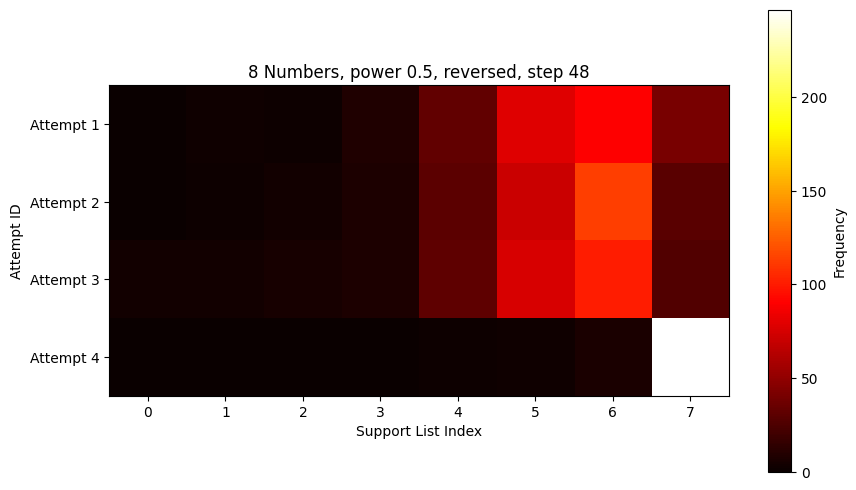

/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-48.pdf
/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-48.png


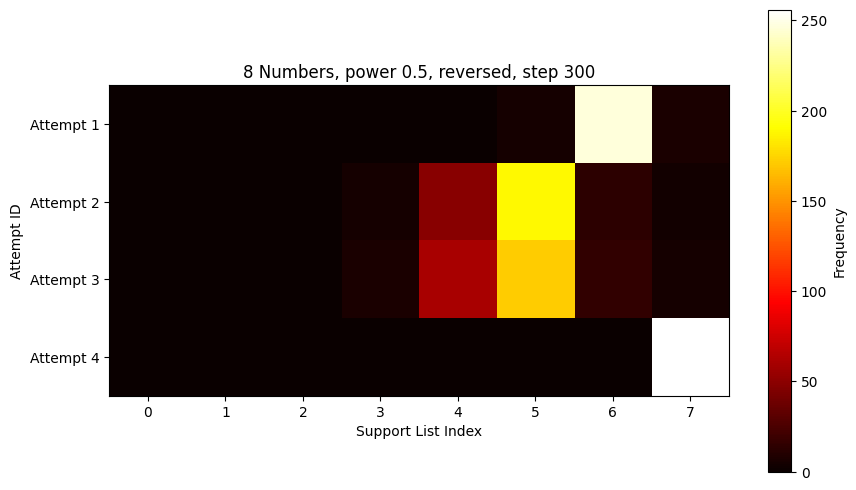

/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-300.pdf
/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-300.png


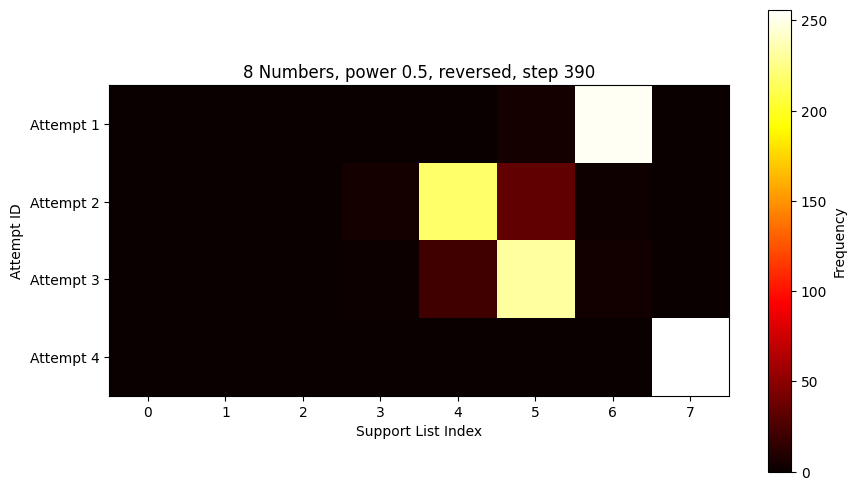

/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-390.pdf
/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-390.png


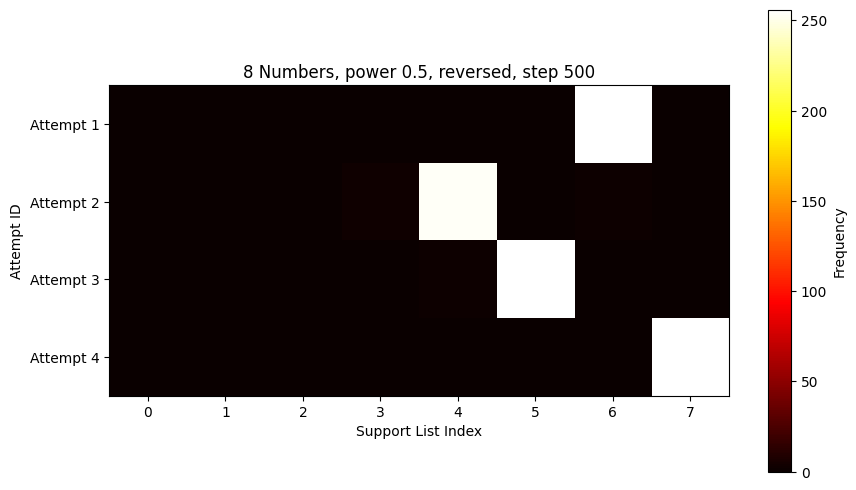

/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-500.pdf
/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/heatmap-500.png


In [11]:
# Example usage
# exp_paths = {
#     "8 Numbers, power 0.9": "/users/stalaei/code/pass_at_k/rollouts/number_guessing/7b_number_guessing_1to100_8_nums_power_9_10_512_20250912_154646/train/56.jsonl",
#     "8 Numbers, power 0.5": "/users/stalaei/code/pass_at_k/rollouts/number_guessing/7b_number_guessing_1to100_8_nums_power_1_2_512_20250912_150250/train/100.jsonl",
#     "8 Numbers, power 0.5, reversed": "/users/stalaei/code/pass_at_k/rollouts/number_guessing/7b_number_guessing_1to100_8_nums_power_1_2_reversed_512_20250912_184416/train/30.jsonl",
#     "4 numbers, implicit, uniform": "/users/stalaei/code/pass_at_k/rollouts/number_guessing/7b_implicit_sets_4_uniform_1024_20250912_184308/train/80.jsonl"
# }

exp_paths = {
    "8 Numbers, power 0.5, reversed, step 48": "/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/48.jsonl",
    "8 Numbers, power 0.5, reversed, step 300": "/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/300.jsonl",
    "8 Numbers, power 0.5, reversed, step 390": "/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/390.jsonl",
    "8 Numbers, power 0.5, reversed, step 500": "/scratch/m000122/stalaei/logs/pass_at_k/rollouts/number_guessing/Qwen2.5-3B-Instruct_number_guessing_1_100_8_nums_power_1_2_reversed/single_attempt_group_based_adv_1024_20250925_125722/train/500.jsonl",
}

for exp_name, data_path in exp_paths.items():
    create_and_save_heatmap(exp_name, data_path)

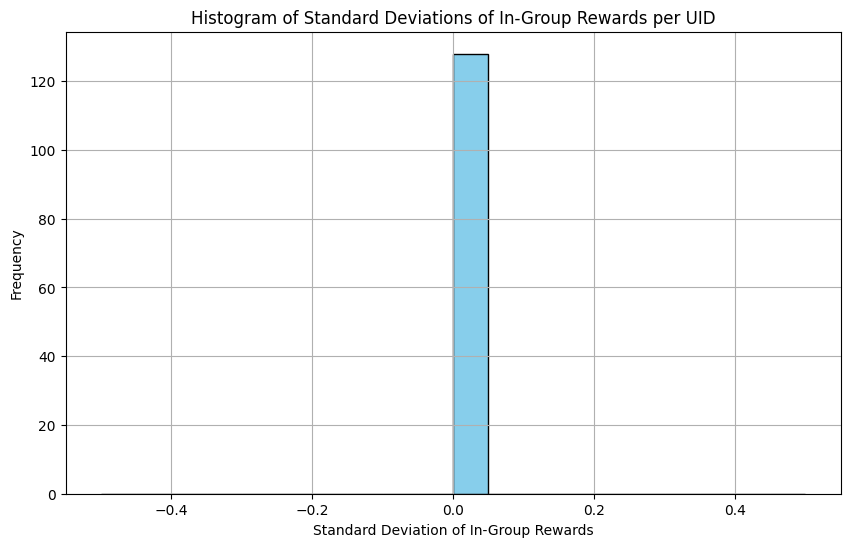

In [8]:
path = "/users/stalaei/code/pass_at_k/rollouts/number_guessing/7b_no_kl_number_guessing_1to100_8_nums_power_1_2_reversed_512_20250913_131316/train/48.jsonl"
# path = "/users/stalaei/code/pass_at_k/rollouts/number_guessing/7b_no_kl_number_guessing_1to100_8_nums_power_1_2_reversed_512_20250913_131316/train/10.jsonl"

import json
import matplotlib.pyplot as plt
import numpy as np

# Initialize a dictionary to store in_group_rewards for each uid
uid_rewards = {}

# Read the JSONL file and collect in_group_rewards for each uid
with open(path, 'r') as file:
    for line in file:
        data = json.loads(line)
        uid = data['uid']
        in_group_reward = data['in_group_reward']
        
        if uid not in uid_rewards:
            uid_rewards[uid] = []
        
        uid_rewards[uid].append(in_group_reward)

# Calculate the standard deviation of in_group_rewards for each uid
stds = [np.std(rewards) for rewards in uid_rewards.values()]

# Plot the histogram of standard deviations
plt.figure(figsize=(10, 6))
plt.hist(stds, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Standard Deviation of In-Group Rewards')
plt.ylabel('Frequency')
plt.title('Histogram of Standard Deviations of In-Group Rewards per UID')
plt.grid(True)
plt.show()


In [9]:
all([std==0 for std in stds])

True

In [10]:
uid_rewards

{'80199d50-e8ad-4ba7-9257-7a4e6b6e5320': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 '84a9f3d3-5431-496d-a118-afa417a37238': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'd971d2f8-7a7f-4a1d-b71c-d76ddc64e730': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 '349aea80-ef6d-498a-b7c7-7a5753cfad6a': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'e270bc73-5e19-4c53-839d-c948d01103cf': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 '0decef46-b493-4690-8cdf-f8f6ce241917': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'a7230636-89db-4a30-a128-43aa01f551f4': [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
